# Visualisation du masquage à la parcelle RPG

Ce notebook permet de :
1. Visualiser le masque parcellaire rasterisé sur quelques patchs
2. Montrer l'image S2 avant/après masquage
3. Comparer les métriques calculées sur **tous les pixels** vs **uniquement les pixels parcelle**

In [1]:
import sys
import json
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Patch

from lib.parcel_mask import ParcelMaskGenerator
from dataloader_CIRCA.datasets.cr_metrics_nina import CloudRemovalMetrics

## 1. Chargement du générateur de masques parcellaires

In [2]:
GPKG_PATH = "/mnt/stores/store_dai/projets/pac/3str/EXP_2/Data_Vecteur/CIRCA+_parcels_full.gpkg"
PATCHES_JSON = "./data/CIRCA_patches_datasets_with_transforms.json"

gen = ParcelMaskGenerator(gpkg_path=GPKG_PATH, patches_json_path=PATCHES_JSON)
print(f"Nombre de patchs indexés : {len(gen._patch_meta)}")

Loading parcel geometries from /mnt/stores/store_dai/projets/pac/3str/EXP_2/Data_Vecteur/CIRCA+_parcels_full.gpkg...
  Loaded 684082 parcels in CRS EPSG:2154
Nombre de patchs indexés : 6966


## 2. Visualisation du masque parcellaire sur quelques patchs

  Reprojecting parcels to CRS 32631...


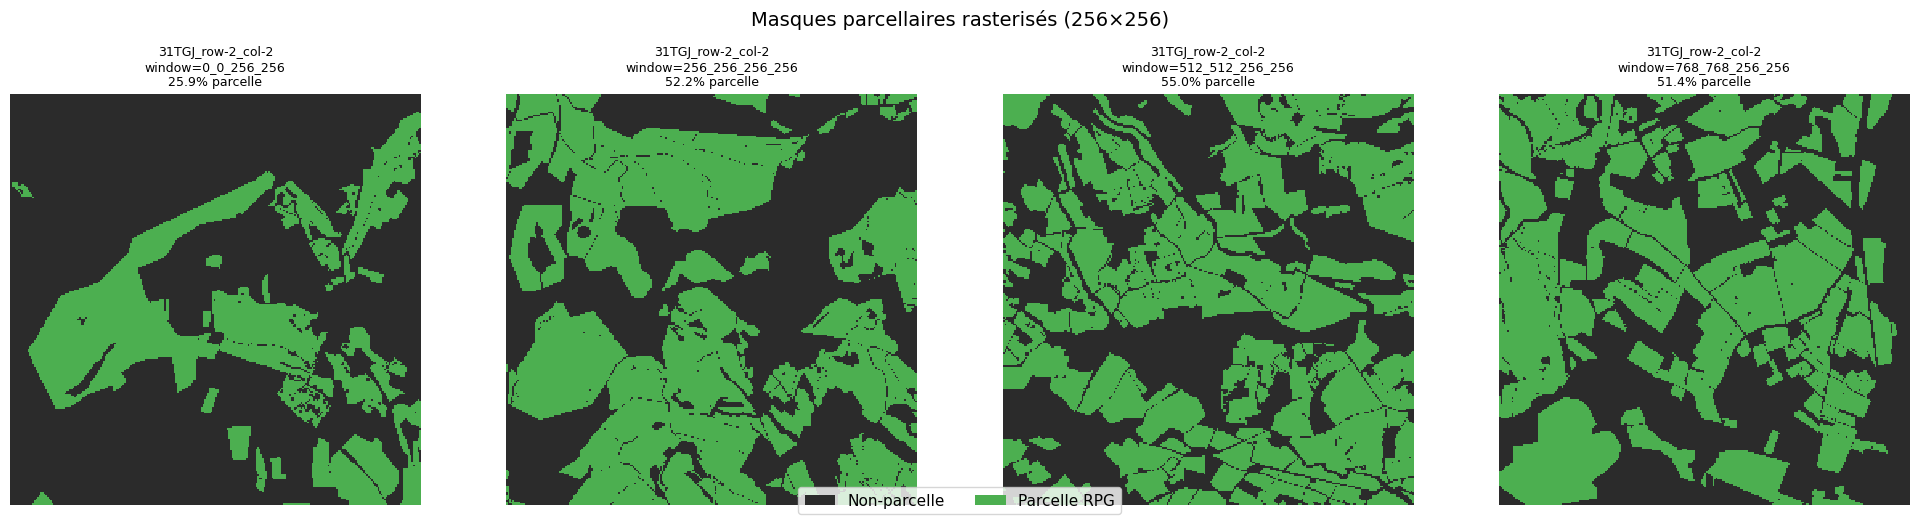

In [3]:
# Sélection de quelques patchs d'exemple (diversité de couverture parcellaire)
sample_patches = [
    ("31TGJ_row-2_col-2", "0_0_256_256"),
    ("31TGJ_row-2_col-2", "256_256_256_256"),
    ("31TGJ_row-2_col-2", "512_512_256_256"),
    ("31TGJ_row-2_col-2", "768_768_256_256"),
]

fig, axes = plt.subplots(1, len(sample_patches), figsize=(5 * len(sample_patches), 5))
for ax, (mgrs25, window) in zip(axes, sample_patches):
    mask = gen.get_mask(mgrs25, window).squeeze().numpy()
    pct = 100 * mask.mean()
    cmap = mcolors.ListedColormap(["#2b2b2b", "#4CAF50"])
    ax.imshow(mask, cmap=cmap, interpolation="nearest", vmin=0, vmax=1)
    ax.set_title(f"{mgrs25}\nwindow={window}\n{pct:.1f}% parcelle", fontsize=9)
    ax.axis("off")

legend_elements = [Patch(facecolor="#2b2b2b", label="Non-parcelle"),
                   Patch(facecolor="#4CAF50", label="Parcelle RPG")]
fig.legend(handles=legend_elements, loc="lower center", ncol=2, fontsize=11)
fig.suptitle("Masques parcellaires rasterisés (256×256)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 3. Chargement d'un échantillon du dataset et prédiction

In [4]:
from omegaconf import OmegaConf
from lib import config_utils
from lib.data_utils import get_dataset

CONFIG_PATH = "./configs/config_run_eval.yaml"
config = config_utils.read_config(CONFIG_PATH)

# Charger la config du modèle entraîné
test_config = config_utils.read_config(config.test_data.test_config)
args_test_data = test_config.data.copy()
if config.test_data.get("hdf5_file"):
    args_test_data.hdf5_file = config.test_data.hdf5_file
if config.test_data.get("split"):
    args_test_data.split = config.test_data.split

# Fusionner avec la config data
full_config = config.copy()
if full_config.data.get("hdf5_file", False):
    for key in ["hdf5_file", "hdf5_file_read"]:
        if key in args_test_data:
            args_test_data.pop(key)
    args_test_data.hdf5_file = full_config.data.hdf5_file
full_config.data.update(args_test_data)
full_config.data.max_seq_length = None

dset = get_dataset(full_config, phase="test")
print(f"Dataset : {len(dset)} échantillons")

Loaded transforms from ./data/CIRCA_patches_datasets_with_transforms.json.
Dataset : 2376 échantillons


In [5]:
# Chargement du modèle
from lib.eval_tools import Imputation

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
imputation = Imputation(
    config_file_train=CONFIG_PATH,
    method=config.get("method", OmegaConf.create({"model_type": "utilise"})).model_type,
    mode=config.test_data.get("mode", None),
    checkpoint=config.test_data.checkpoint,
    config_file_test=config.test_data.test_config,
    num_channels=dset.num_channels,
    device=device,
)
print(f"Modèle chargé sur {device}")

Checkpoint '/home/SPeillet/data_rpg/outputs/U-TILISE/results/all_bands_sar_closest_mix_random_fully_masked_da/2026-03-14_10-59/checkpoints/Model_best.pth' loaded.
Chosen epoch: 24

Modèle chargé sur cuda:0


In [6]:
from torch.utils.data import DataLoader

# Prendre quelques samples
N_SAMPLES = 5
loader = DataLoader(dset, batch_size=1, shuffle=True)
samples = []
for i, batch in enumerate(loader):
    if i >= N_SAMPLES:
        break
    with torch.no_grad():
        batch, y_pred = imputation.impute_sample(batch)
    samples.append((batch, y_pred))
    print(f"  Sample {i}: mgrs25={batch['info']['mgrs25'][0]}, window={batch['info']['window'][0]}")

print(f"\n{len(samples)} échantillons chargés avec prédictions")

  Sample 0: mgrs25=31UFP_row-4_col-4, window=1024_1280_256_256
  Sample 1: mgrs25=31TFJ_row-3_col-2, window=1536_1792_256_256
  Sample 2: mgrs25=31TFN_row-2_col-4, window=1280_1792_256_256
  Sample 3: mgrs25=31UDR_row-4_col-4, window=1280_1536_256_256
  Sample 4: mgrs25=31UFP_row-3_col-2, window=1280_1536_256_256

5 échantillons chargés avec prédictions


## 4. Visualisation : Image S2, masque parcellaire, et pixels utilisés pour les métriques

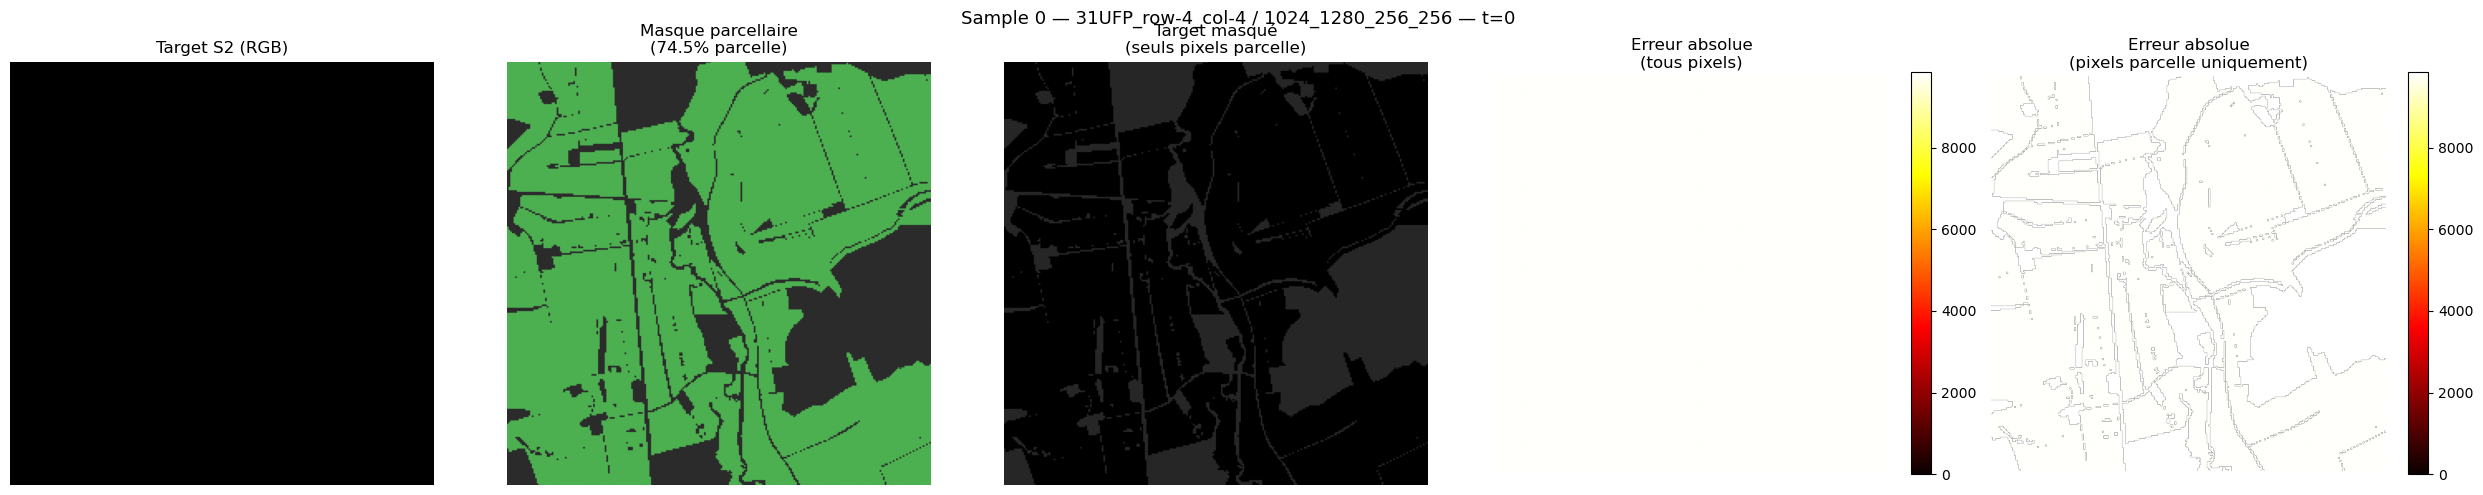

GEOSException: TopologyException: unable to assign free hole to a shell at 638740.27419547481 4835795.606287295

In [7]:
from dataloader_CIRCA.tools.data_processor import SentinelDataProcessor

MAX_PIX = 10_000
T_DISPLAY = 0  # timestep à afficher

for idx, (batch, y_pred) in enumerate(samples):
    mgrs25 = batch["info"]["mgrs25"][0]
    window_str = batch["info"]["window"][0]

    # Masque parcellaire
    parcel_mask = gen.get_mask(mgrs25, window_str).squeeze().numpy()  # (H, W)

    # Image target (dénormalisée) — RGB = bandes 2,1,0
    target = SentinelDataProcessor.reverse_process_MS(batch["y"], intensity_max=MAX_PIX)
    pred = SentinelDataProcessor.reverse_process_MS(y_pred, intensity_max=MAX_PIX)
    cloud_mask = batch.get("cloud_mask", None)

    # Extraire le timestep
    t = min(T_DISPLAY, target.shape[1] - 1)
    tgt_rgb = target[0, t, [2, 1, 0]].permute(1, 2, 0).numpy() / MAX_PIX
    pred_rgb = pred[0, t, [2, 1, 0]].permute(1, 2, 0).numpy() / MAX_PIX
    tgt_rgb = np.clip(tgt_rgb * 3, 0, 1)  # Rehaussement pour mieux voir
    pred_rgb = np.clip(pred_rgb * 3, 0, 1)

    # Masque synthétique d'occlusion
    synth_mask = batch["masks"][0, t, 0].numpy()

    # Image masquée par les parcelles
    tgt_masked = tgt_rgb.copy()
    tgt_masked[parcel_mask == 0] = [0.15, 0.15, 0.15]  # pixels hors parcelle en gris foncé

    # Carte d'erreur absolue
    error = np.abs(target[0, t].numpy() - pred[0, t].detach().numpy()).mean(axis=0)  # (H, W) moyenne sur bandes
    error_parcels = error.copy()
    error_parcels[parcel_mask == 0] = np.nan  # masquer hors parcelle

    fig, axes = plt.subplots(1, 5, figsize=(25, 5))
    axes[0].imshow(tgt_rgb)
    axes[0].set_title("Target S2 (RGB)")

    cmap_mask = mcolors.ListedColormap(["#2b2b2b", "#4CAF50"])
    axes[1].imshow(parcel_mask, cmap=cmap_mask, vmin=0, vmax=1)
    axes[1].set_title(f"Masque parcellaire\n({100*parcel_mask.mean():.1f}% parcelle)")

    axes[2].imshow(tgt_masked)
    axes[2].set_title("Target masqué\n(seuls pixels parcelle)")

    im3 = axes[3].imshow(error, cmap="hot", vmin=0, vmax=np.nanpercentile(error, 98))
    axes[3].set_title("Erreur absolue\n(tous pixels)")
    plt.colorbar(im3, ax=axes[3], fraction=0.046)

    im4 = axes[4].imshow(error_parcels, cmap="hot", vmin=0, vmax=np.nanpercentile(error[parcel_mask == 1], 98) if parcel_mask.sum() > 0 else 1)
    axes[4].set_title("Erreur absolue\n(pixels parcelle uniquement)")
    plt.colorbar(im4, ax=axes[4], fraction=0.046)

    for ax in axes:
        ax.axis("off")

    fig.suptitle(f"Sample {idx} — {mgrs25} / {window_str} — t={t}", fontsize=13)
    plt.tight_layout()
    plt.show()

## 5. Comparaison des métriques : tous pixels vs pixels parcelle uniquement

On calcule les métriques avec et sans masquage parcellaire pour montrer l'effet du filtrage.

In [ ]:
metrics_list = ["mae", "mse", "rmse", "psnr", "ssim", "sam"]

cr_metrics = CloudRemovalMetrics(
    metrics=metrics_list,
    eval_occluded_observed=True,
    clean_gt_cloudy_pixels=True,
    max_pixel_intensity=MAX_PIX,
)

results_all = []  # métriques sur TOUS les pixels
results_parcel = []  # métriques UNIQUEMENT sur pixels parcelle

for idx, (batch, y_pred) in enumerate(samples):
    mgrs25 = batch["info"]["mgrs25"][0]
    window_str = batch["info"]["window"][0]

    target = SentinelDataProcessor.reverse_process_MS(batch["y"], intensity_max=MAX_PIX)
    pred = SentinelDataProcessor.reverse_process_MS(y_pred, intensity_max=MAX_PIX)
    cloud_masks = batch.get("cloud_mask", None)

    # --- Sans masquage parcelle ---
    m_all = cr_metrics(
        target=target,
        masks=batch["masks"],
        predicted=pred,
        cloud_masks=cloud_masks,
    )
    m_all["sample"] = f"{mgrs25}/{window_str}"
    results_all.append(m_all)

    # --- Avec masquage parcelle ---
    parcel_mask = gen.get_mask(mgrs25, window_str)  # (1, 1, H, W)
    non_parcel = (1 - parcel_mask)  # (1, 1, H, W)
    T = target.shape[1]
    non_parcel_exp = non_parcel.unsqueeze(1).expand(-1, T, -1, -1, -1)  # (1, T, 1, H, W)
    if cloud_masks is not None:
        cloud_masks_parcel = torch.clamp(cloud_masks + non_parcel_exp, 0, 1)
    else:
        cloud_masks_parcel = non_parcel_exp

    m_parcel = cr_metrics(
        target=target,
        masks=batch["masks"],
        predicted=pred,
        cloud_masks=cloud_masks_parcel,
    )
    m_parcel["sample"] = f"{mgrs25}/{window_str}"
    results_parcel.append(m_parcel)

print(f"Métriques calculées pour {len(samples)} échantillons")

In [ ]:
import pandas as pd

# Construire un DataFrame comparatif
display_metrics = ["mae", "rmse", "psnr", "ssim", "sam"]

rows = []
for i in range(len(samples)):
    sample_name = results_all[i]["sample"]
    for m in display_metrics:
        val_all = results_all[i].get(m, np.nan)
        val_parcel = results_parcel[i].get(m, np.nan)
        rows.append({
            "Sample": sample_name,
            "Métrique": m.upper(),
            "Tous pixels": round(val_all, 4) if not np.isnan(val_all) else np.nan,
            "Pixels parcelle": round(val_parcel, 4) if not np.isnan(val_parcel) else np.nan,
        })

df_compare = pd.DataFrame(rows)
print("Comparaison des métriques : tous pixels vs pixels parcelle uniquement")
print("=" * 75)
display(df_compare.pivot_table(index="Métrique", columns=[], values=["Tous pixels", "Pixels parcelle"], aggfunc="mean").round(4))

In [ ]:
# Tableau détaillé par sample
df_pivot = df_compare.pivot_table(index="Sample", columns="Métrique", values=["Tous pixels", "Pixels parcelle"])
df_pivot.columns = [f"{col[1]} ({col[0]})" for col in df_pivot.columns]
display(df_pivot.round(4))

In [ ]:
# Graphique comparatif
fig, axes = plt.subplots(1, len(display_metrics), figsize=(4 * len(display_metrics), 5))

for ax, metric in zip(axes, display_metrics):
    vals_all = [results_all[i].get(metric, np.nan) for i in range(len(samples))]
    vals_parcel = [results_parcel[i].get(metric, np.nan) for i in range(len(samples))]

    x = np.arange(len(samples))
    width = 0.35
    bars1 = ax.bar(x - width/2, vals_all, width, label="Tous pixels", color="#607D8B", alpha=0.8)
    bars2 = ax.bar(x + width/2, vals_parcel, width, label="Pixels parcelle", color="#4CAF50", alpha=0.8)
    ax.set_title(metric.upper(), fontsize=12, fontweight="bold")
    ax.set_xticks(x)
    ax.set_xticklabels([f"S{i}" for i in range(len(samples))], fontsize=9)
    ax.tick_params(axis="y", labelsize=9)
    if metric == display_metrics[0]:
        ax.legend(fontsize=8)

fig.suptitle("Comparaison des métriques : Tous pixels vs Pixels parcelle RPG", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 6. Statistiques de couverture parcellaire sur l'ensemble du dataset

In [ ]:
# Calculer le % de couverture parcellaire pour un sous-ensemble de patchs
all_keys = list(gen._patch_meta.keys())
n_check = min(200, len(all_keys))
rng = np.random.default_rng(42)
subset_keys = [all_keys[i] for i in rng.choice(len(all_keys), size=n_check, replace=False)]

coverages = []
for mgrs25, window in subset_keys:
    mask = gen.get_mask(mgrs25, window).squeeze().numpy()
    coverages.append(100 * mask.mean())

coverages = np.array(coverages)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.hist(coverages, bins=30, color="#4CAF50", edgecolor="white", alpha=0.85)
ax1.axvline(coverages.mean(), color="red", linestyle="--", label=f"Moyenne = {coverages.mean():.1f}%")
ax1.set_xlabel("Couverture parcellaire (%)")
ax1.set_ylabel("Nombre de patchs")
ax1.set_title(f"Distribution de la couverture parcellaire\n(n={n_check} patchs)")
ax1.legend()

ax2.boxplot(coverages, vert=True)
ax2.set_ylabel("Couverture parcellaire (%)")
ax2.set_title("Boxplot")

plt.tight_layout()
plt.show()

print(f"Couverture parcellaire moyenne : {coverages.mean():.1f}%")
print(f"Médiane : {np.median(coverages):.1f}%")
print(f"Min : {coverages.min():.1f}% — Max : {coverages.max():.1f}%")
print(f"Patchs sans aucune parcelle : {(coverages == 0).sum()} / {n_check}")